In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
txt_path = "/content/drive/MyDrive/Pushpak/presol2"
txt_files = os.listdir(txt_path)
totalLength = len(txt_files)
test_length = int(totalLength * 0.15)

In [3]:
data_path = "/content/drive/MyDrive/Pushpak/Dataset"
data = os.listdir(data_path)
update_data = []
for i in range(len(data)):
  temp = data[i].split(".")[0] + ".txt"
  if temp in txt_files:
    update_data.append(data[i])

In [4]:
print(len(update_data))

2850


In [5]:
# get test data
width = 32
height = 32
test_image = []
y_value = []
for i in range(test_length):
  try:
    image = cv2.imread(data_path + "/" + data[i], cv2.IMREAD_GRAYSCALE)
    if(image.shape != None):
      center = []
      temp_list = []
      # read txt file and get center
      with open(txt_path + "/" + txt_files[i]) as file:
        for temp in file:
          temp_list.append(temp)
        for temp in temp_list:
          if "q" in temp:
            continue
          else:
            if "mcp" in temp:
              y_value.append("mcp")
              t = temp.split(" ")
              center.append((int(t[1]), int(t[2])))
            elif "pip" in temp:
              y_value.append("pip")
              t = temp.split(" ")
              center.append((int(t[1]), int(t[2])))
            elif "dip" in temp:
              y_value.append("dip")
              t = temp.split(" ")
              center.append((int(t[1]), int(t[2])))
      # get specific location
      for i in range(len(center)):
        min_x = int(center[i][0] - width / 2)
        max_x = int(center[i][0] + width / 2)
        min_y = int(center[i][1] - height / 2)
        max_y = int(center[i][1] + height / 2)
        temp_image = image[min_x:min_x+32, min_y:min_y+32]
        test_image.append(temp_image)
  except:
    pass

In [6]:
print(test_image[0].shape)

(32, 32)


In [7]:
deleted_index = []
for i in range(len(test_image)):
  if test_image[i].shape != (32, 32):
    deleted_index.append(i)

In [8]:
for i in sorted(deleted_index, reverse=True):
  del test_image[i]
  del y_value[i]

In [9]:
# get train images
train_image = []

y_train = []
for i in range(test_length, 1500):
  try:
    image = cv2.imread(data_path + "/" + data[i], cv2.IMREAD_GRAYSCALE)
    if(image.shape != None):
      center = []
      temp_list = []
      # read txt file and get center
      with open(txt_path + "/" + txt_files[i]) as file:
        for temp in file:
          temp_list.append(temp)
        for temp in temp_list:
          if "q" in temp:
            continue
          else:
            if "mcp" in temp:
              y_train.append("mcp")
              t = temp.split(" ")
              center.append((int(t[1]), int(t[2])))
            elif "pip" in temp:
              y_train.append("pip")
              t = temp.split(" ")
              center.append((int(t[1]), int(t[2])))
            elif "dip" in temp:
              y_train.append("dip")
              t = temp.split(" ")
              center.append((int(t[1]), int(t[2])))
      # get specific location
      for i in range(len(center)):
        min_x = int(center[i][0] - width / 2)
        max_x = int(center[i][0] + width / 2)
        min_y = int(center[i][1] - height / 2)
        max_y = int(center[i][1] + height / 2)
        temp_image = image[min_x:min_x+32, min_y:min_y+32]
        train_image.append(temp_image)
  except:
    pass

In [10]:
deleted_index = []
for i in range(len(train_image)):
  if train_image[i].shape != (32, 32):
    deleted_index.append(i)

In [11]:
for i in sorted(deleted_index, reverse=True):
  del train_image[i]
  del y_train[i]

In [12]:
test_data = np.array(test_image)
train_data = np.array(train_image)
print(train_data.shape)
print(test_data.shape)

(12136, 32, 32)
(4853, 32, 32)


In [13]:
test_data = test_data.reshape(test_data.shape[0], test_data.shape[1], test_data.shape[2], 1)
train_data = train_data.reshape(train_data.shape[0], train_data.shape[1], train_data.shape[2], 1)
print(train_data.shape)
print(test_data.shape)

(12136, 32, 32, 1)
(4853, 32, 32, 1)


In [14]:
# label encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y_train)

y_train_update = le.transform(y_train)
y_test_update = le.transform(y_value)

In [15]:
# categorical values
from keras.utils import to_categorical
train_labels = to_categorical(y_train_update)
test_labels = to_categorical(y_test_update)

In [16]:
import keras
import tensorflow as tf

from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalMaxPooling2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

In [17]:
model = Sequential()
model.add(Conv2D(32,(4,4),input_shape = (32,32,1),activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Conv2D(32,(4,4),input_shape = (32,32,1),activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Flatten())
model.add(Dense(128, activation ='relu'))
model.add(Dense(32, activation ='relu'))
model.add(Dense(3, activation ='softmax'))
model.compile(loss ='categorical_crossentropy', optimizer ='adam', metrics =['accuracy'])

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 29, 29, 32)        544       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        16416     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 800)               0         
                                                                 
 dense (Dense)               (None, 128)               1

In [19]:
history = model.fit(train_data, train_labels, epochs = 20, verbose=1,validation_data=(test_data, test_labels))

Epoch 1/20
380/380 [==============================] - 20s 49ms/step - loss: 1.1746 - accuracy: 0.3368 - val_loss: 1.0979 - val_accuracy: 0.3388
Epoch 2/20
380/380 [==============================] - 18s 47ms/step - loss: 1.0987 - accuracy: 0.3356 - val_loss: 1.0989 - val_accuracy: 0.3375
Epoch 3/20
380/380 [==============================] - 19s 50ms/step - loss: 1.0977 - accuracy: 0.3365 - val_loss: 1.1007 - val_accuracy: 0.3414
Epoch 4/20
380/380 [==============================] - 19s 50ms/step - loss: 1.1015 - accuracy: 0.3485 - val_loss: 1.0978 - val_accuracy: 0.3402
Epoch 5/20
380/380 [==============================] - 18s 47ms/step - loss: 1.0968 - accuracy: 0.3359 - val_loss: 1.1023 - val_accuracy: 0.3371
Epoch 6/20
380/380 [==============================] - 19s 49ms/step - loss: 1.0967 - accuracy: 0.3419 - val_loss: 1.1049 - val_accuracy: 0.3381
Epoch 7/20
380/380 [==============================] - 18s 49ms/step - loss: 1.0986 - accuracy: 0.3406 - val_loss: 1.1026 - val_accuracy:

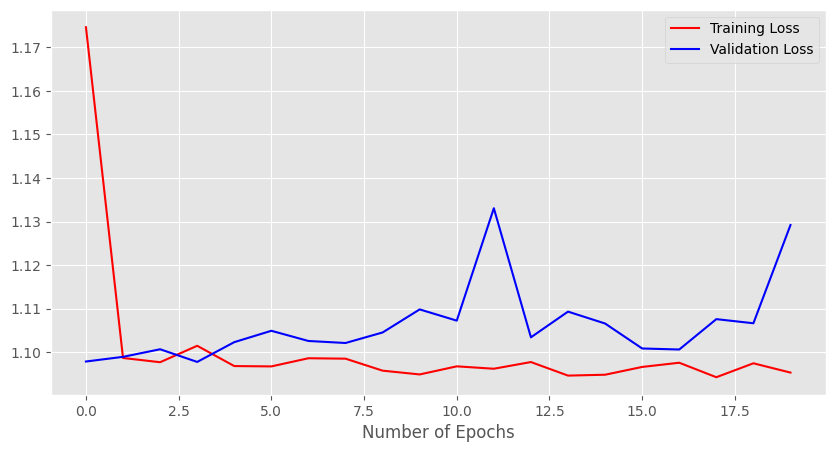

In [21]:
import matplotlib.pyplot as plt
# Plot the error and accuracy
h = history.history
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
plt.plot(h['loss'], c='red', label='Training Loss')
plt.plot(h['val_loss'], c='blue', label='Validation Loss')
plt.xlabel("Number of Epochs")
plt.legend(loc='best')
plt.show()

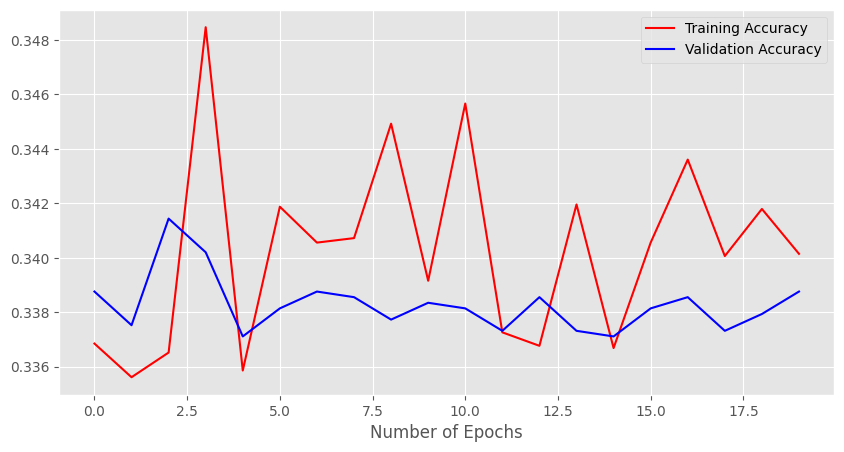

In [22]:
# Plot the error and accuracy
h = history.history
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
plt.plot(h['accuracy'], c='red', label='Training Accuracy')
plt.plot(h['val_accuracy'], c='blue', label='Validation Accuracy')
plt.xlabel("Number of Epochs")
plt.legend(loc='best')
plt.show()

In [23]:
y_pred = model.predict(test_data)

152/152 [==============================] - 2s 15ms/step


In [27]:
y_update = []
for i in range(len(y_pred)):
  y_update.append(np.argmax(y_pred[i]))


[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy: ", round(accuracy_score(y_update, y_test_update) * 100, 2), "%")
print("F1 Score: ", round(f1_score(y_update, y_test_update, average='macro') * 100, 2), "%")
print("Precision: ", round(precision_score(y_update, y_test_update, average='macro') * 100, 2), "%")
print("Recall: ", round(recall_score(y_update, y_test_update, average='macro') * 100, 2), "%")

Accuracy:  33.88 %
F1 Score:  17.75 %
Precision:  33.38 %
Recall:  46.4 %
